In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import gpytorch

from torch.distributions import Normal
from gpytorch.mlls import ExactMarginalLogLikelihood

from botorch.fit import fit_gpytorch_mll
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms import Standardize
from botorch.models.cost import AffineFidelityCostModel

from botorch.acquisition.analytic import AnalyticAcquisitionFunction
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.sampling.normal import IIDNormalSampler
from botorch.optim import optimize_acqf
from botorch.utils.sampling import draw_sobol_samples
from botorch.utils.transforms import t_batch_mode_transform

from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedBranin

warnings.filterwarnings('ignore')

tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double
torch.set_default_dtype(dtype)


In [2]:
# ------------------------------------------------------------
# Helpers
# ------------------------------------------------------------

def draw_initial(
    f,
    n: int = 20,
    flag_two_fid: bool = False,
):
    """
    Generate an initial design with *continuous* fidelities.

    Same style as your existing mf_ei / non-myopic continuous notebooks:
      - sample x-part uniformly in bounds
      - sample fidelity uniformly in bounds
      - force 20% points to highest fidelity
    """

    dim_x = f.dim - (2 if flag_two_fid else 1)
    bounds = f.bounds.clone().to(dtype=dtype, device=device)

    # 1) sample design variables x in their bounds
    low_x = bounds[0, :dim_x]
    high_x = bounds[1, :dim_x]
    u_x = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low_x + (high_x - low_x) * u_x

    # 2) sample continuous fidelity variable(s) in their bounds
    n_fid = 2 if flag_two_fid else 1
    low_s = bounds[0, dim_x: dim_x + n_fid]
    high_s = bounds[1, dim_x: dim_x + n_fid]
    u_s = torch.rand(n, n_fid, dtype=torch.double, device=device)
    s_part = low_s + (high_s - low_s) * u_s

    # 2b) force 20% high-fidelity points
    hf_prop = 0.20
    n_hf = max(1, int(round(hf_prop * n)))
    idx = torch.randperm(n, device=device)[:n_hf]
    s_part[idx, :] = 1.0

    # 3) build full X and evaluate
    X0 = torch.cat([x_part, s_part], dim=-1)
    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0


def fit_mf_gp(X: torch.Tensor, Y: torch.Tensor, fid_dim: int) -> SingleTaskMultiFidelityGP:
    model = SingleTaskMultiFidelityGP(
        train_X=X,
        train_Y=Y,
        data_fidelities=[fid_dim],
        linear_truncated=True,
        outcome_transform=Standardize(m=1),
    ).to(dtype=torch.double, device=device)

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    model.eval()
    return model


def _cost_values(cost_model: AffineFidelityCostModel, X: torch.Tensor) -> torch.Tensor:
    Xe = X if X.dim() == 3 else X.unsqueeze(-2)
    return cost_model(Xe).squeeze(-1).squeeze(-1)


def _best_f_high_model_scale(model, X: torch.Tensor, Y: torch.Tensor, fid_dim: int, s_hi: float = 1.0, tol: float = 1e-3) -> float:
    mask = torch.isclose(
        X[:, fid_dim],
        torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
        atol=tol,
        rtol=0.0,
    )
    if not mask.any():
        raise RuntimeError("No high-fidelity observations found; expected guaranteed HF init points.")
    return float(Y[mask].max().item())  # raw scale


def _noise_std_from_model(model, floor: float = 1e-8) -> float:
    noise = getattr(model.likelihood, "noise", None)
    if noise is None:
        return float(floor)
    nv = torch.as_tensor(noise, dtype=model.train_inputs[0].dtype, device=model.train_inputs[0].device)
    return float(nv.mean().clamp_min(floor**2).sqrt().item())


In [3]:
# # ------------------------------------------------------------
# # Paper MFEI (continuous fidelity)
# # ------------------------------------------------------------

# class PaperMFEIContinuous(AnalyticAcquisitionFunction):
#     """
#     U_MFEI(x,s) = EI_hi(x) * alpha1 * alpha2 * alpha3
#     with continuous fidelity in one designated column.
#     """

#     def __init__(
#         self,
#         model,
#         fid_dim: int,
#         target_fidelity: float,
#         cost_model: AffineFidelityCostModel,
#         best_f: float,
#         noise_std: float,
#         eps: float = 1e-12,
#         posterior_transform=None,
#     ):
#         super().__init__(model=model, posterior_transform=posterior_transform)
#         self.fid_dim = int(fid_dim)
#         self.s_hi = float(target_fidelity)
#         self.cost_model = cost_model
#         self.best_f = float(best_f)
#         self.noise_std = float(noise_std)
#         self.eps = float(eps)

#         self._std_normal = Normal(
#             torch.zeros(1, dtype=model.train_targets.dtype, device=model.train_targets.device),
#             torch.ones(1, dtype=model.train_targets.dtype, device=model.train_targets.device),
#         )

#     @t_batch_mode_transform(expected_q=1)
#     def forward(self, X: torch.Tensor) -> torch.Tensor:
#         X_hi = project_to_target_fidelity(X, target_fidelities={self.fid_dim: self.s_hi})
#         X_pair = torch.cat([X, X_hi], dim=-2)

#         post_pair = self.model.posterior(X_pair, posterior_transform=self.posterior_transform)
#         mean2 = post_pair.mean.squeeze(-1)
#         var2 = post_pair.variance.squeeze(-1).clamp_min(self.eps)
#         cov = post_pair.mvn.covariance_matrix[..., 0, 1]

#         mu_hi = mean2[..., 1]
#         var_s = var2[..., 0]
#         var_hi = var2[..., 1]

#         alpha1 = (cov / (var_s.sqrt() * var_hi.sqrt() + self.eps)).clamp(-1.0, 1.0)

#         sigma_hi = var_hi.sqrt().clamp_min(self.eps)
#         z = (mu_hi - self.best_f) / sigma_hi
#         ei_hi = (mu_hi - self.best_f) * self._std_normal.cdf(z) + sigma_hi * torch.exp(self._std_normal.log_prob(z))

#         # sigma_eps = torch.as_tensor(self.noise_std, dtype=X.dtype, device=X.device).clamp_min(self.eps)
#         # alpha2 = 1.0 - sigma_eps / torch.sqrt(var_s + sigma_eps.square())

#         c_hi = _cost_values(self.cost_model, X_hi)
#         c_s = _cost_values(self.cost_model, X).clamp_min(self.eps)
#         alpha3 = c_hi / c_s

#         val = torch.nan_to_num(ei_hi * alpha1  * alpha3, nan=0.0, posinf=0.0, neginf=0.0)

#         # For fantasy models we may get extra model-batch dimensions; collapse safely.
#         expected_ndim = len(X.shape[:-2])
#         while val.dim() > expected_ndim:
#             val = val.squeeze(0) if val.size(0) == 1 else val.mean(dim=0)

#         return val


In [4]:
from botorch.acquisition.analytic import AnalyticAcquisitionFunction, _log_ei_helper
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.utils.transforms import t_batch_mode_transform


class PaperMFEIContinuous(AnalyticAcquisitionFunction):
    """
    U_MFEI(x,s) = EI_hi(x) * alpha1 * alpha2 * alpha3
    with continuous fidelity in one designated column.

    This version uses LogEI + nan guards.
    """

    def __init__(
        self,
        model,
        fid_dim: int,
        target_fidelity: float,
        cost_model: AffineFidelityCostModel,
        best_f: float,
        noise_std: float,
        eps: float = 1e-12,
        posterior_transform=None,
    ):
        super().__init__(model=model, posterior_transform=posterior_transform)
        self.fid_dim = int(fid_dim)
        self.s_hi = float(target_fidelity)
        self.cost_model = cost_model
        self.best_f = float(best_f)      # keep in raw scale consistently
        self.noise_std = float(noise_std)
        self.eps = float(eps)

        dt = model.train_inputs[0].dtype
        dv = model.train_inputs[0].device
        self._best_f_t = torch.as_tensor(self.best_f, dtype=dt, device=dv)



    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        X_hi = project_to_target_fidelity(X, target_fidelities={self.fid_dim: self.s_hi})
        X_pair = torch.cat([X, X_hi], dim=-2)

        post_pair = self.model.posterior(X_pair, posterior_transform=self.posterior_transform)

        mean2 = torch.nan_to_num(
            post_pair.mean.squeeze(-1), nan=0.0, posinf=1e6, neginf=-1e6
        )
        var2 = torch.nan_to_num(
            post_pair.variance.squeeze(-1), nan=self.eps, posinf=1e6, neginf=self.eps
        ).clamp_min(self.eps)
        cov = torch.nan_to_num(
            post_pair.mvn.covariance_matrix[..., 0, 1], nan=0.0, posinf=0.0, neginf=0.0
        )

        var_s = var2[..., 0]
        var_hi = var2[..., 1]

        denom = (var_s.sqrt() * var_hi.sqrt()).clamp_min(self.eps)
        alpha1 = (cov / denom).clamp(-1.0, 1.0)
        alpha1 = torch.nan_to_num(alpha1, nan=0.0, posinf=0.0, neginf=0.0)

        mu_hi = mean2[..., 1]
        var_s = var2[..., 0]
        var_hi = var2[..., 1]

        sigma_hi = var_hi.sqrt().clamp_min(self.eps)
        best_f_t = torch.as_tensor(self.best_f, dtype=mu_hi.dtype, device=mu_hi.device)
        u = torch.nan_to_num((mu_hi - best_f_t) / sigma_hi, nan=0.0, posinf=1e6, neginf=-1e6)

        log_ei_hi = sigma_hi.log() + _log_ei_helper(u)
        log_ei_hi = torch.nan_to_num(log_ei_hi, nan=-50.0, posinf=50.0, neginf=-50.0)
        ei_hi = torch.exp(log_ei_hi).clamp_min(0.0)
        ei_hi = torch.nan_to_num(ei_hi, nan=0.0, posinf=0.0, neginf=0.0)


        # Optional alpha2 (currently not used, same as your present setup)
        # sigma_eps = torch.as_tensor(self.noise_std, dtype=X.dtype, device=X.device).clamp_min(self.eps)
        # alpha2 = 1.0 - sigma_eps / torch.sqrt(var_s + sigma_eps.square())
        # alpha2 = torch.nan_to_num(alpha2, nan=0.0, posinf=0.0, neginf=0.0)

        c_hi = _cost_values(self.cost_model, X_hi)
        c_s = _cost_values(self.cost_model, X).clamp_min(self.eps)
        alpha3 = c_hi / c_s
        alpha3 = torch.nan_to_num(alpha3, nan=0.0, posinf=0.0, neginf=0.0)

        val = torch.nan_to_num(ei_hi * alpha1 * alpha3, nan=0.0, posinf=0.0, neginf=0.0)

        # Collapse extra model-batch dims from fantasy models
        expected_ndim = len(X.shape[:-2])
        while val.dim() > expected_ndim:
            val = val.squeeze(0) if val.size(0) == 1 else val.mean(dim=0)

        return val


In [5]:
# ------------------------------------------------------------
# Optimizer dispatch: sobol / optimize_acqf / hybrid
# ------------------------------------------------------------

@dataclass
class OptimizerConfig:
    method: str = "sobol"   # "sobol" | "optimize_acqf" | "hybrid"
    sobol_n: int = 128
    num_restarts: int = 4
    raw_samples: int = 64
    maxiter: int = 80
    hybrid_topk: int = 8


NM2_OPT_TRACE = {
    "dispatch_total": 0,
    "outer_dispatch": 0,
    "inner_dispatch": 0,
    "optimize_acqf_total": 0,
    "sobol_total": 0,
}


def _argmax_acq_by_sobol(acq_function, bounds: torch.Tensor, sobol_n: int, seed: int):
    X = draw_sobol_samples(bounds=bounds, n=int(sobol_n), q=1, seed=int(seed)).squeeze(-2)
    with torch.no_grad():
        vals = acq_function(X.unsqueeze(-2)).view(-1)
        vals = torch.nan_to_num(vals, nan=-1e20, posinf=-1e20, neginf=-1e20)
    idx = int(vals.argmax().item())
    return X[idx:idx+1].detach(), float(vals[idx].item())


def _argmax_acq_dispatch(acq_function, bounds: torch.Tensor, cfg: OptimizerConfig, seed: int, call_site: str = "unspecified"):
    NM2_OPT_TRACE["dispatch_total"] += 1
    if call_site == "outer":
        NM2_OPT_TRACE["outer_dispatch"] += 1
    elif call_site == "inner":
        NM2_OPT_TRACE["inner_dispatch"] += 1

    # print(
    #     f"[DISPATCH] id={NM2_OPT_TRACE['dispatch_total']} site={call_site} method={cfg.method} seed={seed}"
    # )

    if cfg.method == "sobol":
        NM2_OPT_TRACE["sobol_total"] += 1
        # print(f"  [SOBOL] call={NM2_OPT_TRACE['sobol_total']} n={int(cfg.sobol_n)}")
        x, v = _argmax_acq_by_sobol(acq_function, bounds, cfg.sobol_n, seed)
        # print(f"  [SOBOL] done best={float(v):.6f}")
        return x, v

    if cfg.method == "optimize_acqf":
        NM2_OPT_TRACE["optimize_acqf_total"] += 1
        opt_id = NM2_OPT_TRACE["optimize_acqf_total"]
        # print(
        #     f"  [optimize_acqf] call={opt_id} restarts={int(cfg.num_restarts)} raw_samples={int(cfg.raw_samples)} maxiter={int(cfg.maxiter)}"
        # )
        x, v = optimize_acqf(
            acq_function=acq_function,
            bounds=bounds,
            q=1,
            num_restarts=int(cfg.num_restarts),
            raw_samples=int(cfg.raw_samples),
            options={
                "maxiter": int(cfg.maxiter),
                "batch_limit": 1,
                # "init_batch_limit": max(16, int(cfg.raw_samples)),
                "with_grad": False,
            },
            return_best_only=True,
        )
        out = float(v.item())
        # print(f"  [optimize_acqf] done call={opt_id} best={out:.6f}")
        return x.detach(), out

    if cfg.method == "hybrid":
        NM2_OPT_TRACE["sobol_total"] += 1
        # print(f"  [HYBRID-SOBOL] call={NM2_OPT_TRACE['sobol_total']} n={int(cfg.sobol_n)}")
        Xs = draw_sobol_samples(bounds=bounds, n=int(cfg.sobol_n), q=1, seed=int(seed)).squeeze(-2)
        with torch.no_grad():
            vals = acq_function(Xs.unsqueeze(-2)).view(-1)
            vals = torch.nan_to_num(vals, nan=-1e20, posinf=-1e20, neginf=-1e20)
        topk = int(max(1, min(cfg.hybrid_topk, cfg.num_restarts, cfg.sobol_n)))
        top_idx = torch.topk(vals, k=topk).indices
        batch_ic = Xs[top_idx].unsqueeze(-2)

        if topk < int(cfg.num_restarts):
            pad = batch_ic[:1].repeat(int(cfg.num_restarts) - topk, 1, 1)
            batch_ic = torch.cat([batch_ic, pad], dim=0)

        NM2_OPT_TRACE["optimize_acqf_total"] += 1
        opt_id = NM2_OPT_TRACE["optimize_acqf_total"]
        # print(
        #     f"  [HYBRID-optimize_acqf] call={opt_id} topk={topk} restarts={int(cfg.num_restarts)} raw_samples={max(1, int(cfg.raw_samples))} maxiter={int(cfg.maxiter)}"
        # )
        x, v = optimize_acqf(
            acq_function=acq_function,
            bounds=bounds,
            q=1,
            num_restarts=int(cfg.num_restarts),
            raw_samples=max(1, int(cfg.raw_samples)),
            batch_initial_conditions=batch_ic,
            options={
                "maxiter": int(cfg.maxiter),
                "batch_limit": 1,
                # "init_batch_limit": max(16, int(cfg.raw_samples)),
                "with_grad": False,
            },
            return_best_only=True,
        )
        out = float(v.item())
        # print(f"  [HYBRID-optimize_acqf] done call={opt_id} best={out:.6f}")
        return x.detach(), out

    raise ValueError(f"Unknown optimizer method: {cfg.method}")


In [6]:
# ------------------------------------------------------------
# NM2 acquisition with BoTorch fantasies
# ------------------------------------------------------------

class NM2Fantasize2StepAcq(AnalyticAcquisitionFunction):
    """
    U_NM2(x1,s1) = U_MFEI(x1,s1) + E_Z[ max_(x2,s2) Uhat_MFEI(x2,s2 | fantasy(x1,s1,Z)) ]

    Fantasy generation uses model.fantasize(...).
    """

    def __init__(
        self,
        model,
        bounds: torch.Tensor,
        fid_dim: int,
        target_fidelity: float,
        cost_model: AffineFidelityCostModel,
        best_f: float,
        noise_std: float,
        n_mc: int,
        inner_opt: OptimizerConfig,
        fantasy_seed_base: int,
        hf_tol: float = 1e-3,
    ):
        super().__init__(model=model)
        self.bounds = bounds
        self.fid_dim = int(fid_dim)
        self.s_hi = float(target_fidelity)
        self.cost_model = cost_model
        self.best_f = float(best_f)
        self.noise_std = float(noise_std)
        self.n_mc = int(n_mc)
        self.inner_opt = inner_opt
        self.fantasy_seed_base = int(fantasy_seed_base)
        self.hf_tol = float(hf_tol)

        self.immediate = PaperMFEIContinuous(
            model=model,
            fid_dim=self.fid_dim,
            target_fidelity=self.s_hi,
            cost_model=self.cost_model,
            best_f=self.best_f,
            noise_std=self.noise_std,
        )

    def _single_value(self, x1: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            u1 = self.immediate(x1.unsqueeze(-2)).reshape(-1)[0]

        s1 = float(x1[0, self.fid_dim].item())
        is_hi = abs(s1 - self.s_hi) <= self.hf_tol
        Xq = x1.unsqueeze(-2)

        # print(
        #     f"[NM2::_single_value] x1={x1.detach().cpu().numpy().round(4).tolist()} s1={s1:.4f} is_hi={is_hi} n_mc={self.n_mc}"
        # )

        inner_vals = []
        for m in range(self.n_mc):
            seed_m = self.fantasy_seed_base + m
            sampler = IIDNormalSampler(sample_shape=torch.Size([1]), seed=seed_m)
            # print(f"  [Fantasy {m+1}/{self.n_mc}] seed={seed_m} -> fantasize")

            # Build fantasy model
            fmodel = self.model.fantasize(X=Xq, sampler=sampler, observation_noise=None)
            # print(
            #     f"  [Fantasy {m+1}/{self.n_mc}] train_targets_shape={tuple(fmodel.train_targets.shape)}"
            # )

            # Update incumbent threshold only if first-step query is high fidelity
            y1_t = fmodel.train_targets[..., -1].reshape(-1, 1)
            if getattr(fmodel, "outcome_transform", None) is not None:
                y1_raw, _ = fmodel.outcome_transform.untransform(y1_t)
                y1 = y1_raw.reshape(-1)[0]
            else:
                y1 = y1_t.reshape(-1)[0]
            y1 = torch.nan_to_num(
                y1,
                nan=torch.as_tensor(self.best_f, dtype=y1.dtype, device=y1.device),
                posinf=torch.as_tensor(self.best_f, dtype=y1.dtype, device=y1.device),
                neginf=torch.as_tensor(self.best_f, dtype=y1.dtype, device=y1.device),
            )
            best_f_fant = max(self.best_f, float(y1.item())) if is_hi else self.best_f
            # print(
            #     f"  [Fantasy {m+1}/{self.n_mc}] y1={float(y1.item()):.6f} best_f_fant={best_f_fant:.6f}"
            # )

            inner_acq = PaperMFEIContinuous(
                model=fmodel,
                fid_dim=self.fid_dim,
                target_fidelity=self.s_hi,
                cost_model=self.cost_model,
                best_f=best_f_fant,
                noise_std=self.noise_std,
            )
            # print(f"  [Fantasy {m+1}/{self.n_mc}] inner optimization dispatch")
            _, inner_best = _argmax_acq_dispatch(
                acq_function=inner_acq,
                bounds=self.bounds,
                cfg=self.inner_opt,
                seed=seed_m + 1_000_000,
                call_site="inner",
            )
            # print(f"  [Fantasy {m+1}/{self.n_mc}] inner_best={float(inner_best):.6f}")
            inner_vals.append(torch.as_tensor(inner_best, dtype=x1.dtype, device=x1.device))

        if inner_vals:
            inner_mean = torch.stack(inner_vals).mean()
            # print(
            #     f"[NM2::_single_value] fantasies_done={len(inner_vals)} values_collected={len(inner_vals)} inner_mean={float(inner_mean.item()):.6f}"
            # )
            return u1 + inner_mean

        # print("[NM2::_single_value] no fantasy values; returning immediate term only")
        return u1

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        d = X.size(-1)
        Xflat = X.reshape(-1, 1, d)
        # print(
        #     f"[NM2::forward] candidates={Xflat.size(0)} expected_inner_dispatches={Xflat.size(0) * self.n_mc}"
        # )
        vals = []
        for i in range(Xflat.size(0)):
            x1 = Xflat[i, 0, :].unsqueeze(0)
            vals.append(self._single_value(x1))
        # print(f"[NM2::forward] done candidates={Xflat.size(0)}")
        return torch.stack(vals).reshape(X.shape[:-2])


def select_next_nm2_fantasize(
    model,
    train_X: torch.Tensor,
    train_Y: torch.Tensor,
    bounds: torch.Tensor,
    fid_dim: int,
    target_fidelity: float,
    cost_model: AffineFidelityCostModel,
    n_mc: int,
    outer_opt: OptimizerConfig,
    inner_opt: OptimizerConfig,
    iter_seed: int,
    hf_tol: float = 1e-3,
    noise_floor: float = 1e-8,
):
    best_f = _best_f_high_model_scale(
        model=model,
        X=train_X,
        Y=train_Y,
        fid_dim=fid_dim,
        s_hi=target_fidelity,
        tol=hf_tol,
    )
    noise_std = _noise_std_from_model(model, floor=noise_floor)

    # print(
    #     f"[select_next_nm2_fantasize] iter_seed={iter_seed} best_f={best_f:.6f} noise_std={noise_std:.6f} n_mc={n_mc}"
    # )

    acq = NM2Fantasize2StepAcq(
        model=model,
        bounds=bounds,
        fid_dim=fid_dim,
        target_fidelity=target_fidelity,
        cost_model=cost_model,
        best_f=best_f,
        noise_std=noise_std,
        n_mc=n_mc,
        inner_opt=inner_opt,
        fantasy_seed_base=10_000 * int(iter_seed),
        hf_tol=hf_tol,
    )

    x_next, v_next = _argmax_acq_dispatch(
        acq_function=acq,
        bounds=bounds,
        cfg=outer_opt,
        seed=iter_seed,
        call_site="outer",
    )
    print(f"[select_next_nm2_fantasize] chosen nm2={float(v_next):.6f}")
    return x_next, v_next


In [16]:
# ------------------------------------------------------------
# BO loop (same style as your continuous non-myopic notebook)
# ------------------------------------------------------------

@dataclass
class NM2RunConfig:
    T: int = 35
    init_n: int = 32
    n_mc: int = 8
    target_fidelity: float = 1.0
    hf_tol: float = 1.1e-2
    noise_floor: float = 1e-8
    outer_opt: OptimizerConfig = field(default_factory=lambda: OptimizerConfig(method='optimize_acqf', sobol_n=128, num_restarts=6, raw_samples=96, maxiter=120))
    inner_opt: OptimizerConfig = field(default_factory=lambda: OptimizerConfig(method='sobol', sobol_n=64, num_restarts=2, raw_samples=32, maxiter=50))


def run_cost_aware_nm2_bo_once(
    f,
    cfg: NM2RunConfig,
    cost_dict: dict | None = None,
    seed: int | None = None,
    per_run_plots: bool = True,
):
    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))

    fid_dim = f.dim - 1
    bounds = f.bounds.clone().detach().to(**tkwargs)

    if cost_dict is None:
        cost_dict = {"fixed_cost": 5.0, "w": 1.0}

    fixed_cost = float(cost_dict.get("fixed_cost", 5.0))
    w = float(cost_dict.get("w", 1.0))
    cost_model = AffineFidelityCostModel(fidelity_weights={fid_dim: w}, fixed_cost=fixed_cost)

    X, Y = draw_initial(
        f=f,
        n=cfg.init_n,
        flag_two_fid=False,
    )
    # print(f"Initial X: {X.detach().cpu().numpy().round(4)}")
    # print(f"Initial Y: {Y.detach().cpu().numpy().round(4)}")

    iter_idx, cum_cost_hist, best_hi_hist = [], [], []
    nm2_hist, s_hist = [], []

    total_cost = 0.0
    hf0 = torch.isclose(
        X[:, fid_dim],
        torch.as_tensor(cfg.target_fidelity, dtype=X.dtype, device=X.device),
        atol=cfg.hf_tol,
        rtol=0.0,
    )
    prev_best = float(Y[hf0].max().item()) if hf0.any() else float('-inf')

    for t in range(cfg.T):
        model = fit_mf_gp(X, Y, fid_dim=fid_dim)

        trace_before = dict(NM2_OPT_TRACE)
        new_x, nm2_val = select_next_nm2_fantasize(
            model=model,
            train_X=X,
            train_Y=Y,
            bounds=bounds,
            fid_dim=fid_dim,
            target_fidelity=cfg.target_fidelity,
            cost_model=cost_model,
            n_mc=cfg.n_mc,
            outer_opt=cfg.outer_opt,
            inner_opt=cfg.inner_opt,
            iter_seed=(0 if seed is None else int(seed)) + t + 1,
            hf_tol=cfg.hf_tol,
            noise_floor=cfg.noise_floor,
        )

        trace_after = dict(NM2_OPT_TRACE)
        print(
            f"[Iter {t+1:02d} dispatch-count] outer={trace_after['outer_dispatch'] - trace_before['outer_dispatch']} "
            f"| inner={trace_after['inner_dispatch'] - trace_before['inner_dispatch']} "
            f"| optimize_acqf={trace_after['optimize_acqf_total'] - trace_before['optimize_acqf_total']} "
            f"| sobol={trace_after['sobol_total'] - trace_before['sobol_total']}"
        )

        with torch.no_grad():
            new_y = f(new_x).view(1, 1)

        cost_t = cost_model(new_x).squeeze(-1).squeeze(-1).item()
        total_cost += float(cost_t)

        X = torch.cat([X, new_x], dim=0)
        Y = torch.cat([Y, new_y], dim=0)

        s_val = float(new_x[0, fid_dim].item())
        if abs(s_val - cfg.target_fidelity) <= cfg.hf_tol:
            prev_best = max(prev_best, float(new_y.item()))

        iter_idx.append(t + 1)
        cum_cost_hist.append(total_cost)
        best_hi_hist.append(prev_best)
        nm2_hist.append(float(nm2_val))
        s_hist.append(s_val)

        print(
            f"Iter {t+1:02d} | s={s_val:.4f} | y={float(new_y.item()):.6f} "
            f"| nm2={float(nm2_val):.6f} | cost={float(cost_t):.6f} "
            f"| cum_cost={float(total_cost):.6f} | best_hf={float(prev_best):.6f}"
        )

        del model

    if per_run_plots:
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost")
        plt.ylabel(f"Best observed @ s≈{cfg.target_fidelity}")
        plt.title("Best high fidelity vs cumulative cost (NM2 fantasize)")
        plt.grid(True)
        plt.show()

    return {
        "cum_cost": cum_cost_hist,
        "best_hi": best_hi_hist,
        "nm2": nm2_hist,
        "chosen_s": s_hist,
    }


In [8]:
# ------------------------------------------------------------
# Run wrappers + aggregation + plotting (same style)
# ------------------------------------------------------------
from tests import AugmentedBukin, AugmentedRastrigin
from tests import SuzukiMFEmulator


def run_single(f, seed: int, total_iters: int = 35, n_mc: int = 8, outer_method: str = 'hybrid', inner_method: str = 'hybrid'):
    if isinstance(f, AugmentedHartmann):
        cost_dict = {"fixed_cost": 5.0, "w": 1.0}
    elif isinstance(f, AugmentedBranin):
        cost_dict = {"fixed_cost": 5.0, "w": 1.0}
    elif isinstance(f, (AugmentedRastrigin)):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
    elif isinstance(f, SuzukiMFEmulator):
        cost_dict    = {"fixed_cost": 5.0, "w": 1.0}  # cost increases with fidelity
    else:
        raise ValueError("Unknown function")

    cfg = NM2RunConfig(
        T=total_iters,
        init_n=32,
        n_mc=n_mc,
        outer_opt=OptimizerConfig(method=outer_method, sobol_n=64, num_restarts=3, raw_samples=32, maxiter=50, hybrid_topk=8),
        inner_opt=OptimizerConfig(method=inner_method, sobol_n=64, num_restarts=3, raw_samples=32, maxiter=50, hybrid_topk=8),
        # outer_opt=OptimizerConfig(method=outer_method, sobol_n=128, num_restarts=3, raw_samples=32, maxiter=50, hybrid_topk=8),
        # inner_opt=OptimizerConfig(method=inner_method, sobol_n=64, num_restarts=3, raw_samples=48, maxiter=80, hybrid_topk=6),
    )

    results = run_cost_aware_nm2_bo_once(
        f=f,
        cfg=cfg,
        cost_dict=cost_dict,
        seed=seed,
        per_run_plots=True,
    )

    df = pd.DataFrame({
        "iteration": np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi": results["best_hi"],
        "nm2_value": results["nm2"],
        "chosen_s": results["chosen_s"],
    })
    return df


def aggregate_runs(dfs):
    merged = (
        pd.concat({i: df.set_index("iteration") for i, df in enumerate(dfs)}, names=["run", "iteration"])
        .reset_index(level="run")
    )
    stats = merged.groupby("iteration").agg(["mean", "std"])
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()


def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()


def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std, title="Best observed vs. cumulative cost (mean ± 1 σ)"):
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean, best_mean - best_std, best_mean + best_std, alpha=0.25, label="±1 σ (best)")
    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



=== Running rastrigin (iters=50) ===
[select_next_nm2_fantasize] chosen nm2=13.131606
[Iter 01 dispatch-count] outer=1 | inner=9560 | optimize_acqf=1 | sobol=9560
Iter 01 | s=1.0000 | y=-55.959440 | nm2=13.131606 | cost=6.000000 | cum_cost=6.000000 | best_hf=-50.473383
[select_next_nm2_fantasize] chosen nm2=8.889660
[Iter 02 dispatch-count] outer=1 | inner=4520 | optimize_acqf=1 | sobol=4520
Iter 02 | s=0.8643 | y=-16.812570 | nm2=8.889660 | cost=5.864299 | cum_cost=11.864299 | best_hf=-50.473383
[select_next_nm2_fantasize] chosen nm2=32.330082
[Iter 03 dispatch-count] outer=1 | inner=5440 | optimize_acqf=1 | sobol=5440
Iter 03 | s=0.9678 | y=-18.041392 | nm2=32.330082 | cost=5.967793 | cum_cost=17.832092 | best_hf=-50.473383
[select_next_nm2_fantasize] chosen nm2=11.871835
[Iter 04 dispatch-count] outer=1 | inner=4360 | optimize_acqf=1 | sobol=4360
Iter 04 | s=0.8759 | y=-66.315294 | nm2=11.871835 | cost=5.875899 | cum_cost=23.707990 | best_hf=-50.473383
[select_next_nm2_fantasize] c

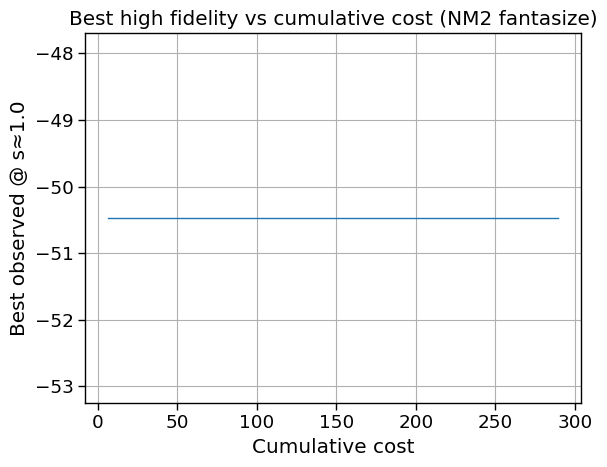

[select_next_nm2_fantasize] chosen nm2=7.759935
[Iter 01 dispatch-count] outer=1 | inner=19760 | optimize_acqf=1 | sobol=19760
Iter 01 | s=0.8770 | y=-27.753799 | nm2=7.759935 | cost=5.877003 | cum_cost=5.877003 | best_hf=-42.253938
[select_next_nm2_fantasize] chosen nm2=15.200971
[Iter 02 dispatch-count] outer=1 | inner=5480 | optimize_acqf=1 | sobol=5480
Iter 02 | s=0.9844 | y=-35.483791 | nm2=15.200971 | cost=5.984373 | cum_cost=11.861376 | best_hf=-42.253938
[select_next_nm2_fantasize] chosen nm2=11.018540
[Iter 03 dispatch-count] outer=1 | inner=22800 | optimize_acqf=1 | sobol=22800
Iter 03 | s=0.9890 | y=-32.796043 | nm2=11.018540 | cost=5.989000 | cum_cost=17.850376 | best_hf=-42.253938
[select_next_nm2_fantasize] chosen nm2=6.988365
[Iter 04 dispatch-count] outer=1 | inner=6840 | optimize_acqf=1 | sobol=6840
Iter 04 | s=1.0000 | y=-18.373450 | nm2=6.988365 | cost=6.000000 | cum_cost=23.850376 | best_hf=-18.373450
[select_next_nm2_fantasize] chosen nm2=1.995069
[Iter 05 dispatch

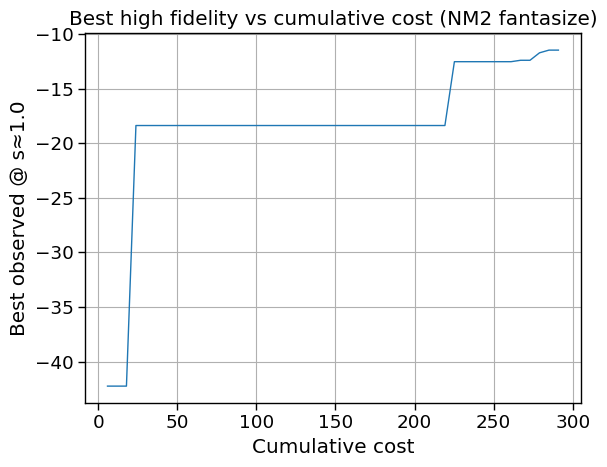

[select_next_nm2_fantasize] chosen nm2=17.035705
[Iter 01 dispatch-count] outer=1 | inner=5120 | optimize_acqf=1 | sobol=5120
Iter 01 | s=0.9163 | y=-56.107235 | nm2=17.035705 | cost=5.916345 | cum_cost=5.916345 | best_hf=-44.994501
[select_next_nm2_fantasize] chosen nm2=11.518538
[Iter 02 dispatch-count] outer=1 | inner=10360 | optimize_acqf=1 | sobol=10360
Iter 02 | s=0.9198 | y=-23.704445 | nm2=11.518538 | cost=5.919751 | cum_cost=11.836096 | best_hf=-44.994501
[select_next_nm2_fantasize] chosen nm2=5.976766
[Iter 03 dispatch-count] outer=1 | inner=7320 | optimize_acqf=1 | sobol=7320
Iter 03 | s=0.8678 | y=-36.061281 | nm2=5.976766 | cost=5.867769 | cum_cost=17.703864 | best_hf=-44.994501
[select_next_nm2_fantasize] chosen nm2=17.057472
[Iter 04 dispatch-count] outer=1 | inner=3720 | optimize_acqf=1 | sobol=3720
Iter 04 | s=0.9571 | y=-26.681478 | nm2=17.057472 | cost=5.957055 | cum_cost=23.660919 | best_hf=-44.994501
[select_next_nm2_fantasize] chosen nm2=6.920680
[Iter 05 dispatch

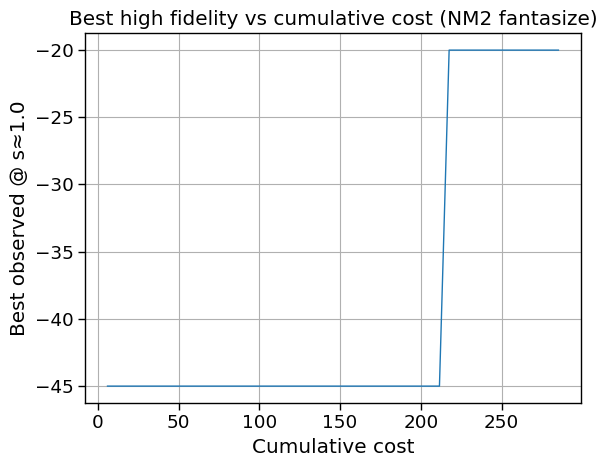

[select_next_nm2_fantasize] chosen nm2=0.257149
[Iter 01 dispatch-count] outer=1 | inner=5640 | optimize_acqf=1 | sobol=5640
Iter 01 | s=0.8388 | y=-40.526388 | nm2=0.257149 | cost=5.838820 | cum_cost=5.838820 | best_hf=-18.746432
[select_next_nm2_fantasize] chosen nm2=0.283973
[Iter 02 dispatch-count] outer=1 | inner=6400 | optimize_acqf=1 | sobol=6400
Iter 02 | s=0.8200 | y=-38.147202 | nm2=0.283973 | cost=5.820010 | cum_cost=11.658829 | best_hf=-18.746432
[select_next_nm2_fantasize] chosen nm2=0.256647
[Iter 03 dispatch-count] outer=1 | inner=4480 | optimize_acqf=1 | sobol=4480
Iter 03 | s=0.8269 | y=-39.721633 | nm2=0.256647 | cost=5.826939 | cum_cost=17.485768 | best_hf=-18.746432
[select_next_nm2_fantasize] chosen nm2=0.323417
[Iter 04 dispatch-count] outer=1 | inner=4240 | optimize_acqf=1 | sobol=4240
Iter 04 | s=0.9331 | y=-45.034303 | nm2=0.323417 | cost=5.933097 | cum_cost=23.418865 | best_hf=-18.746432
[select_next_nm2_fantasize] chosen nm2=0.187236
[Iter 05 dispatch-count] 

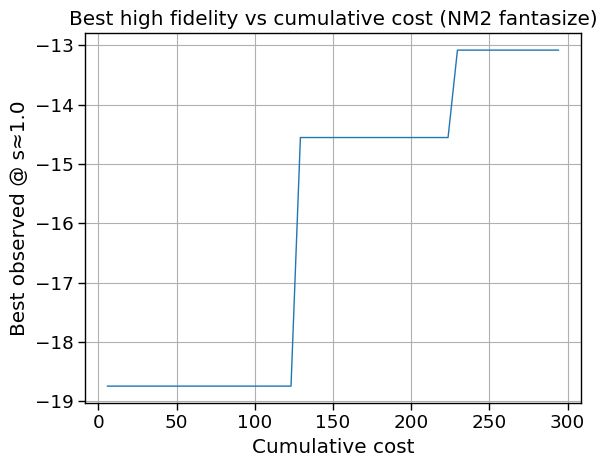

[select_next_nm2_fantasize] chosen nm2=3.098941
[Iter 01 dispatch-count] outer=1 | inner=4880 | optimize_acqf=1 | sobol=4880
Iter 01 | s=0.9755 | y=-40.603076 | nm2=3.098941 | cost=5.975533 | cum_cost=5.975533 | best_hf=-31.370302
[select_next_nm2_fantasize] chosen nm2=3.021561
[Iter 02 dispatch-count] outer=1 | inner=8640 | optimize_acqf=1 | sobol=8640
Iter 02 | s=1.0000 | y=-37.686133 | nm2=3.021561 | cost=6.000000 | cum_cost=11.975533 | best_hf=-31.370302
[select_next_nm2_fantasize] chosen nm2=4.006584
[Iter 03 dispatch-count] outer=1 | inner=30040 | optimize_acqf=1 | sobol=30040
Iter 03 | s=0.9890 | y=-39.391424 | nm2=4.006584 | cost=5.989000 | cum_cost=17.964533 | best_hf=-31.370302
[select_next_nm2_fantasize] chosen nm2=2.424397
[Iter 04 dispatch-count] outer=1 | inner=11400 | optimize_acqf=1 | sobol=11400
Iter 04 | s=0.6712 | y=-75.213520 | nm2=2.424397 | cost=5.671156 | cum_cost=23.635688 | best_hf=-31.370302
[select_next_nm2_fantasize] chosen nm2=3.656241
[Iter 05 dispatch-cou

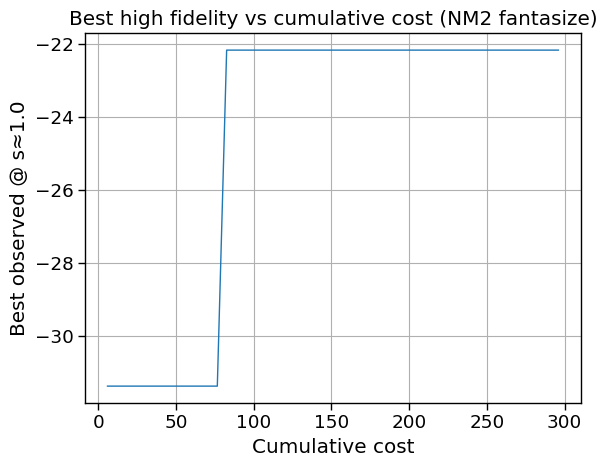

[select_next_nm2_fantasize] chosen nm2=1.025232
[Iter 01 dispatch-count] outer=1 | inner=4280 | optimize_acqf=1 | sobol=4280
Iter 01 | s=0.9332 | y=-29.966666 | nm2=1.025232 | cost=5.933209 | cum_cost=5.933209 | best_hf=-34.841818
[select_next_nm2_fantasize] chosen nm2=3.878365
[Iter 02 dispatch-count] outer=1 | inner=14960 | optimize_acqf=1 | sobol=14960
Iter 02 | s=0.7948 | y=-50.056121 | nm2=3.878365 | cost=5.794773 | cum_cost=11.727982 | best_hf=-34.841818
[select_next_nm2_fantasize] chosen nm2=2.218096
[Iter 03 dispatch-count] outer=1 | inner=3960 | optimize_acqf=1 | sobol=3960
Iter 03 | s=0.8450 | y=-28.573372 | nm2=2.218096 | cost=5.844982 | cum_cost=17.572964 | best_hf=-34.841818
[select_next_nm2_fantasize] chosen nm2=5.855593
[Iter 04 dispatch-count] outer=1 | inner=5880 | optimize_acqf=1 | sobol=5880
Iter 04 | s=0.9890 | y=-29.399392 | nm2=5.855593 | cost=5.989000 | cum_cost=23.561964 | best_hf=-34.841818
[select_next_nm2_fantasize] chosen nm2=7.083481
[Iter 05 dispatch-count

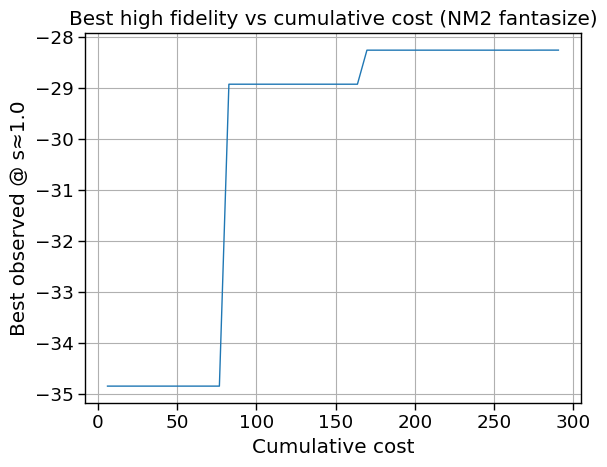

Saved aggregate stats -> nm2_fantasize_runs_cont_rastrigin.csv


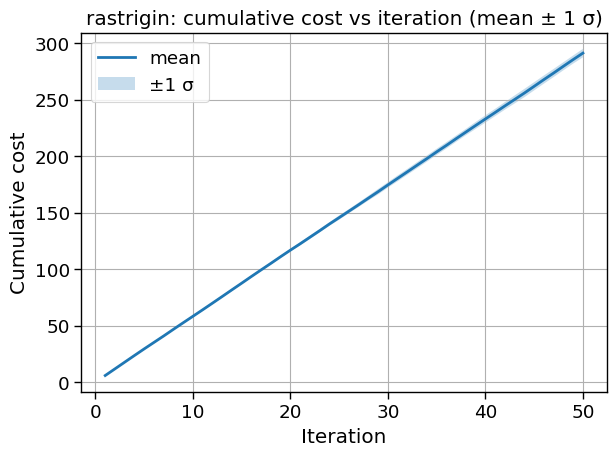

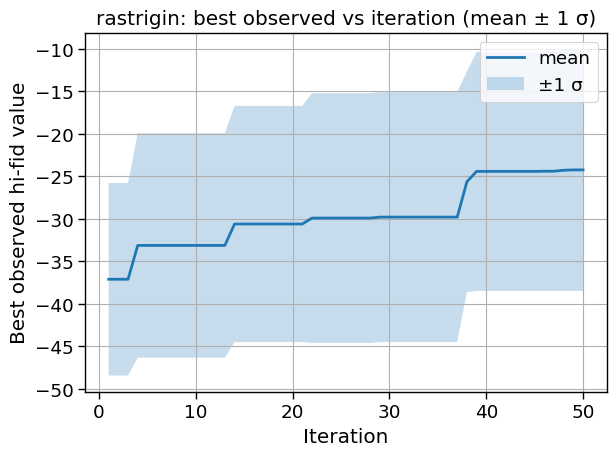

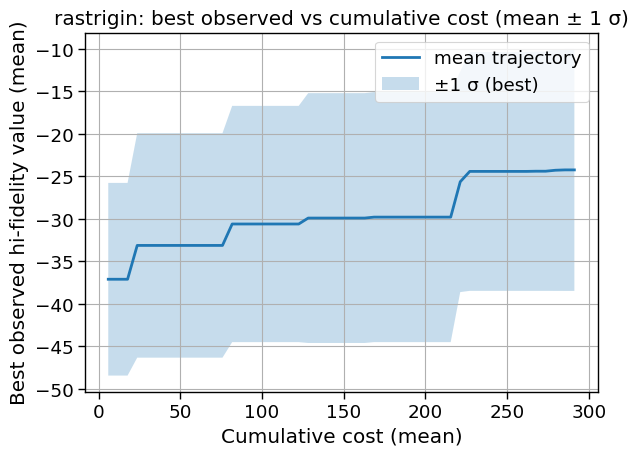

In [17]:
# ------------------------------------------------------------
# Experiments (same style as your continuous notebook)
# ------------------------------------------------------------

benchmarks = OrderedDict([
    # ("branin",   (AugmentedBranin(negate=True), 50)), first 4 seeds
    # ("hartmann", (AugmentedHartmann(negate=True), 60)),
    # ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True),60)),
    ("rastrigin",  (AugmentedRastrigin(dim=3, negate=True), 50)),
])

SEEDS = [33, 42, 88, 105, 67,151]  # 6 runs

for tag, (f, total_iters) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    run_dfs = [
        run_single(
            f=f,
            seed=s,
            total_iters=total_iters,
            n_mc=8,
            outer_method='optimize_acqf',
            inner_method='sobol',
        )
        for s in SEEDS
    ]

    stats_df = aggregate_runs(run_dfs)
    out_csv = f"nm2_fantasize_runs_cont_{tag}.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats -> {out_csv}")

    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        title=f"{tag}: best observed vs cumulative cost (mean ± 1 σ)",
    )

    plt.show()
